## Merge Dataset

In [2]:
import pandas as pd

email_batch_1 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/datasets/category/Email Qwen Category Dataset/email_batch_1_labeled_qwen2.5.csv')
email_batch_2 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/datasets/category/Email Qwen Category Dataset/email_batch_2_labeled_qwen2.5.csv')
email_batch_3 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/datasets/category/Email Qwen Category Dataset/email_batch_3_labeled_qwen2.5.csv')
email_batch_4 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/datasets/category/Email Qwen Category Dataset/email_batch_4_labeled_qwen2.5.csv')
email_batch_5 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/datasets/category/Email Qwen Category Dataset/email_batch_5_labeled_qwen2.5.csv')
email_batch_6 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/datasets/category/Email Qwen Category Dataset/email_batch_6_labeled_qwen2.5.csv')
email_batch_7 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/datasets/category/Email Qwen Category Dataset/email_batch_7_labeled_qwen2.5.csv')
email_batch_8 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/datasets/category/Email Qwen Category Dataset/email_batch_8_labeled_qwen2.5.csv')
email_batch_9 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/datasets/category/Email Qwen Category Dataset/email_batch_9_labeled_qwen2.5.csv')
#email_synthetic_data = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/FYP PART 2/Category Modeling/cleaned_category_synthetic_balanced_full_dataset.csv')

#email_data = pd.concat([email_batch_1, email_batch_2, email_batch_3, email_batch_4, email_batch_5, email_batch_6, email_batch_7, email_batch_8, email_batch_9, email_synthetic_data], ignore_index=True)
email_data = pd.concat([email_batch_1, email_batch_2, email_batch_3, email_batch_4, email_batch_5, email_batch_6, email_batch_7, email_batch_8, email_batch_9], ignore_index=True)

In [2]:
rows, cols = email_data.shape
#print(f"✅ Cleaned and combined CSV saved at:\n{output_file}")
print(f"🧮 Total rows: {rows}")
print(f"🧾 Total columns: {cols}")

🧮 Total rows: 245117
🧾 Total columns: 11


## Simple Exploration

In [3]:
email_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245117 entries, 0 to 245116
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   From              245117 non-null  object
 1   To                238229 non-null  object
 2   Subject           238244 non-null  object
 3   Message           245116 non-null  object
 4   Day               245117 non-null  object
 5   Date & Time       245117 non-null  object
 6   url_count         245117 non-null  int64 
 7   Cleaned_Subject   230176 non-null  object
 8   Cleaned_Message   244499 non-null  object
 9   Combined_Text     245117 non-null  object
 10  Qwen2.5_Category  245117 non-null  object
dtypes: int64(1), object(10)
memory usage: 20.6+ MB


In [4]:
total_rows, total_columns = email_data.shape
print(f"🧮 Total rows: {total_rows}")
print(f"🧾 Total columns: {total_columns}")

🧮 Total rows: 245117
🧾 Total columns: 11


In [3]:
email_data['Qwen2.5_Category'].value_counts()

Qwen2.5_Category
General Business Communication              55127
Finance & Transactions                      35682
Personal Communication & Purely Personal    29053
Meeting & Scheduling                        21720
Legal & Contractual                         15980
Promotion & Newsletter                       5927
IT Alerts & System Notifications             4632
Project Management & Strategy                4205
Spam                                         1815
Internal Policies & HR Updates               1534
Mergers, Partnerships & Alliances             797
Name: count, dtype: int64

In [7]:
# Define spammy keywords
spam_keywords = ['free', 'winner', 'win', 'click here', 'subscribe', 'buy now',
                 'limited time', 'exclusive offer', 'deal', 'discount', 'act now']

# Filter for 'Promotion & Newsletter'
promo_df = email_data[email_data['Qwen2.5_Category'] == 'Promotion & Newsletter'].copy()

# Combine subject and message
promo_df['combined_text'] = promo_df['Subject'].fillna('') + ' ' + promo_df['Message'].fillna('')

# Check for spam-like keywords
promo_df['contains_spam'] = promo_df['combined_text'].str.lower().apply(
    lambda text: any(keyword in text for keyword in spam_keywords)
)

# Summary stats
spammy_count = promo_df['contains_spam'].sum()
total_count = promo_df.shape[0]
percent_spammy = round((spammy_count / total_count) * 100, 2)

print(f"📊 Out of {total_count} 'Promotion & Newsletter' emails:")
print(f"⚠️ {spammy_count} contain spam-like keywords ({percent_spammy}%)")


📊 Out of 5927 'Promotion & Newsletter' emails:
⚠️ 3189 contain spam-like keywords (53.8%)


In [ ]:
promo_df

In [9]:
# Create a condition for spammy Promotion emails
condition = (email_data['Qwen2.5_Category'] == 'Promotion & Newsletter') & (
    email_data['Subject'].fillna('').str.lower() + ' ' + email_data['Message'].fillna('').str.lower()
).apply(lambda text: any(keyword in text for keyword in spam_keywords))

# Relabel them as 'Spam'
email_data.loc[condition, 'Qwen2.5_Category'] = 'Spam'

In [10]:
email_data['Qwen2.5_Category'].value_counts()

Qwen2.5_Category
General Business Communication              55127
Finance & Transactions                      35682
Personal Communication & Purely Personal    29053
Meeting & Scheduling                        21720
IT Alerts & System Notifications            20000
Spam                                        20000
Legal & Contractual                         20000
Project Management & Strategy               20000
Internal Policies & HR Updates              20000
Promotion & Newsletter                       2738
Mergers, Partnerships & Alliances             797
Name: count, dtype: int64

In [11]:
email_data = email_data[email_data['Qwen2.5_Category'] != 'Promotion & Newsletter']

In [12]:
total_rows, total_columns = email_data.shape
print(f"🧮 Total rows: {total_rows}")
print(f"🧾 Total columns: {total_columns}")

🧮 Total rows: 242379
🧾 Total columns: 11


In [14]:
email_data['Qwen2.5_Category'].value_counts()

Qwen2.5_Category
General Business Communication              55127
Finance & Transactions                      35682
Personal Communication & Purely Personal    29053
Meeting & Scheduling                        21720
IT Alerts & System Notifications            20000
Spam                                        20000
Legal & Contractual                         20000
Project Management & Strategy               20000
Internal Policies & HR Updates              20000
Mergers, Partnerships & Alliances             797
Name: count, dtype: int64

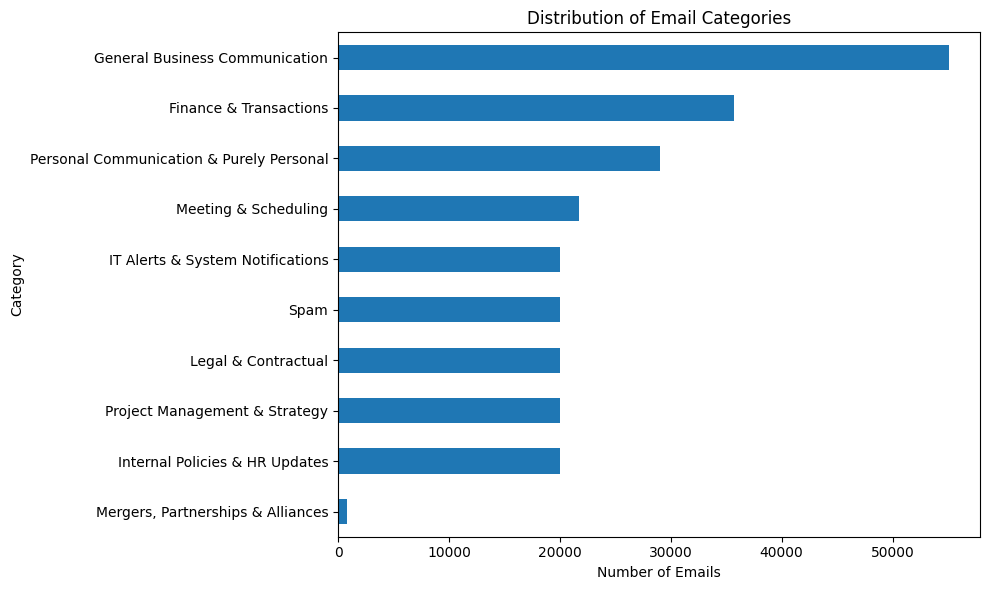

In [15]:
import matplotlib.pyplot as plt

email_data['Qwen2.5_Category'].value_counts().plot(kind='barh', figsize=(10, 6))
plt.title("Distribution of Email Categories")
plt.xlabel("Number of Emails")
plt.ylabel("Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
email_data.isnull().sum()

From                    0
To                   6698
Subject              6790
Message                 1
Day                     0
Date & Time             0
url_count               0
Cleaned_Subject     14818
Cleaned_Message       605
Combined_Text           0
Qwen2.5_Category        0
dtype: int64

In [17]:
email_data['Qwen2.5_Category'] = email_data['Qwen2.5_Category'].replace(
    'Mergers, Partnerships & Alliances', 'General Business Communication'
)

In [20]:
email_data['Qwen2.5_Category'].value_counts()

Qwen2.5_Category
General Business Communication              55924
Finance & Transactions                      35682
Personal Communication & Purely Personal    29053
Meeting & Scheduling                        21720
IT Alerts & System Notifications            20000
Spam                                        20000
Legal & Contractual                         20000
Project Management & Strategy               20000
Internal Policies & HR Updates              20000
Name: count, dtype: int64

In [ ]:
email_data

In [21]:
email_data.to_csv("final_email_category_balanced.csv", index=False)